# 🤟 SignSpeech — Member 5: Live Demo App & Report Lead

**Pipeline summary:**
```
Webcam → [M2] MediaPipe Hand Detection (224×224)
       → [M3+M4] SignSpeechCompletePipeline (CNN + Transformer)
       → Predicted Word + Confidence
       → pyttsx3 TTS (spoken aloud)
       → OpenCV display (word + confidence + hand box)
```

**Your deliverables:**
1. Live demo loop (this notebook)
2. Demo recording (≥5 signs recognized)
3. Final report (abstract, intro, data, results, conclusion)

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    'torch', 'torchvision', 'opencv-python',
    'mediapipe', 'pyttsx3', 'numpy', 'Pillow', 'matplotlib'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All dependencies installed.')

✅ All dependencies installed.


## Cell 2 — Imports

In [2]:
import math
import json
import time
import threading
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import pyttsx3
import mediapipe as mp
from collections import deque
print('✅ All imports successful.')
print(f'   PyTorch : {torch.__version__}')
print(f'   OpenCV  : {cv2.__version__}')
print(f'   Device  : {"CUDA" if torch.cuda.is_available() else "CPU"}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\OMEN\anaconda3\envs\ai_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\OMEN\anaconda3\envs\ai_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\OMEN\anaconda3\envs\ai_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\OMEN\anaconda3\envs\ai_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
 

✅ All imports successful.
   PyTorch : 2.2.2
   OpenCV  : 4.13.0
   Device  : CPU


## Cell 3 — Paste M4's Model Architecture (exact copy from M4's notebook)

In [3]:
class MobileNetFeatureExtractor(nn.Module):
    def __init__(self, freeze_backbone=True):
        super(MobileNetFeatureExtractor, self).__init__()
        self.backbone = models.mobilenet_v2(weights='DEFAULT')
        self.backbone.classifier = nn.Identity()
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        batch_size, timesteps, C, H, W = x.shape
        flat_images = x.view(batch_size * timesteps, C, H, W)
        flat_features = self.backbone(flat_images)
        sequence_features = flat_features.view(batch_size, timesteps, 1280)
        return sequence_features


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x


class SignSpeechTransformer(nn.Module):
    def __init__(self, num_classes=100, d_model=1280, nhead=8,
                 num_layers=2, dim_feedforward=512, dropout=0.1):
        super(SignSpeechTransformer, self).__init__()
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)


class SignSpeechBiLSTM(nn.Module):
    def __init__(self, num_classes=100, input_dim=1280, hidden_dim=256,
                 num_layers=2, dropout=0.2):
        super(SignSpeechBiLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        return self.classifier(out)


class SignSpeechCompletePipeline(nn.Module):
    def __init__(self, temporal_type='transformer', num_classes=100):
        super(SignSpeechCompletePipeline, self).__init__()
        self.spatial_extractor = MobileNetFeatureExtractor(freeze_backbone=True)
        self.temporal_type = temporal_type.lower()
        if self.temporal_type == 'transformer':
            self.temporal_model = SignSpeechTransformer(num_classes=num_classes)
        elif self.temporal_type == 'bilstm':
            self.temporal_model = SignSpeechBiLSTM(num_classes=num_classes)
        else:
            raise ValueError("temporal_type must be 'transformer' or 'bilstm'")

    def forward(self, x):
        spatial_features = self.spatial_extractor(x)
        logits = self.temporal_model(spatial_features)
        return logits

print('✅ Model architecture defined.')

✅ Model architecture defined.


## Cell 4 — Load the Trained Model (.pth from M4)

In [4]:
MODEL_PATH     = r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\SignSpeech_M4\signspeech_transformer_best.pth'
TEMPORAL_TYPE  = 'transformer'
NUM_CLASSES    = 100
LABEL_MAP_PATH = r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\data_prep_output\label_map.json'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

live_model = SignSpeechCompletePipeline(
    temporal_type=TEMPORAL_TYPE,
    num_classes=NUM_CLASSES
)

try:
    live_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print('✅ Trained weights loaded successfully.')
except FileNotFoundError:
    print('⚠️  .pth file not found — running with untrained model.')

live_model.eval()
live_model.to(DEVICE)

try:
    with open(LABEL_MAP_PATH) as f:
        lm = json.load(f)
    idx_to_word = {int(k): v for k, v in lm['idx_to_word'].items()}
    print(f'✅ Label map loaded: {len(idx_to_word)} classes')
except FileNotFoundError:
    labels = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ') + ['space', 'delete', 'nothing']
    idx_to_word = {i: labels[i] for i in range(len(labels))}
    print('⚠️  label_map.json not found — using default alphabet')

print(f'✅ Model ready on {DEVICE}')

✅ Trained weights loaded successfully.
✅ Label map loaded: 100 classes
✅ Model ready on cpu


## Cell 5 — Preprocessing Transform (same as M1/M2)

In [5]:
def preprocess_frame(bgr_frame):
    rgb = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    tensor = torch.tensor(resized.copy().tolist(), dtype=torch.float32) / 255.0
    tensor = tensor.permute(2, 0, 1)
    return tensor
print('✅ Preprocessing ready.')

✅ Preprocessing ready.


## Cell 6 — M2 Hand Detection Helper (MediaPipe)

In [6]:
import urllib.request
import os

# ── Saves the file in the same folder as your notebook ───────────────────────
MODEL_FILE = 'hand_landmarker.task'

if not os.path.exists(MODEL_FILE):
    print('Downloading hand_landmarker.task ... (one time only, ~1MB)')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task',
        MODEL_FILE
    )
    print('✅ Downloaded.')
else:
    print('✅ hand_landmarker.task already exists.')

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base_options = mp_python.BaseOptions(model_asset_path=MODEL_FILE)
hand_options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    running_mode=mp_vision.RunningMode.IMAGE
)
hand_detector = mp_vision.HandLandmarker.create_from_options(hand_options)

def detect_and_crop_hand(bgr_frame, padding=0.20):
    H, W   = bgr_frame.shape[:2]
    rgb    = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = hand_detector.detect(mp_img)

    if not result.hand_landmarks:
        return bgr_frame, None

    landmarks = result.hand_landmarks[0]
    xs = [lm.x for lm in landmarks]
    ys = [lm.y for lm in landmarks]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    w_box = x_max - x_min
    h_box = y_max - y_min
    x_min = max(0.0, x_min - padding * w_box)
    x_max = min(1.0, x_max + padding * w_box)
    y_min = max(0.0, y_min - padding * h_box)
    y_max = min(1.0, y_max + padding * h_box)

    x1, x2 = int(x_min * W), int(x_max * W)
    y1, y2 = int(y_min * H), int(y_max * H)

    crop = bgr_frame[y1:y2, x1:x2]
    if crop.size == 0:
        return bgr_frame, None

    return crop, (x1, y1, x2, y2)

print(f'✅ Hand detector ready (MediaPipe v{mp.__version__})')

✅ hand_landmarker.task already exists.
✅ Hand detector ready (MediaPipe v0.10.35)


## Cell 7 — Inference Function

In [7]:
def predict_sequence(frame_buffer):
    tensors = []
    for frame in frame_buffer:
        crop, _ = detect_and_crop_hand(frame)
        tensors.append(preprocess_frame(crop))
    sequence = torch.stack(tensors, dim=0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = live_model(sequence)
        probs = torch.softmax(logits, dim=1)[0]
    top5_probs, top5_idxs = torch.topk(probs, k=5)
    top5 = [(idx_to_word[i.item()], p.item()) for i, p in zip(top5_idxs, top5_probs)]
    return top5[0][0], top5[0][1], top5

# Test with dummy frames
dummy_frames = [np.zeros((480, 640, 3), dtype=np.uint8) for _ in range(32)]
word, conf, top5 = predict_sequence(dummy_frames)
print('✅ Inference pipeline OK')
print(f'   Dummy prediction : "{word}" ({conf*100:.1f}%)')

✅ Inference pipeline OK
   Dummy prediction : "hearing" (2.9%)


## Cell 8 — TTS Setup (pyttsx3)

In [8]:
import pyttsx3
import threading

def test_tts():
    try:
        engine = pyttsx3.init()
        engine.setProperty('rate', 150)
        engine.setProperty('volume', 1.0)
        engine.say('SignSpeech system ready')
        engine.runAndWait()
        engine.stop()
        print('✅ TTS working')
    except Exception as e:
        print(f'❌ TTS error: {e}')

test_tts()

def speak_async(text):
    def _speak():
        try:
            engine = pyttsx3.init()
            engine.setProperty('rate', 150)
            engine.setProperty('volume', 1.0)
            engine.say(text)
            engine.runAndWait()
            engine.stop()
        except Exception as e:
            print(f'⚠️ TTS failed: {e}')
    t = threading.Thread(target=_speak, daemon=True)
    t.start()

print('✅ TTS ready')

✅ TTS working
✅ TTS ready


## Cell 9 — Live Demo Loop (Main Application)

> **How to use:**  
> 1. Run this cell → a webcam window opens.  
> 2. Hold your hand in front of the camera and **hold the sign still** while the progress bar fills (32 frames).  
> 3. The predicted word appears on screen and is **spoken aloud**.  
> 4. Press **`Q`** to quit.

In [ ]:
FRAMES_NEEDED        = 100
CONFIDENCE_THRESHOLD = 0.10
CAMERA_INDEX         = 0
DISPLAY_WIDTH        = 960
DISPLAY_HEIGHT       = 540

try:
    cap.release()
    cv2.destroyAllWindows()
except:
    pass

CLR_GREEN  = (0, 220, 100)
CLR_YELLOW = (0, 215, 255)
CLR_RED    = (60,  60, 220)
CLR_WHITE  = (255, 255, 255)
CLR_DARK   = (20,  20,  20)
CLR_ACCENT = (255, 180,  0)

def draw_overlay(frame, frame_buffer, last_word, last_conf, last_top5, bbox, fps):
    H, W = frame.shape[:2]

    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (W, 60), CLR_DARK, -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    cv2.putText(frame, 'SignSpeech', (14, 40),
                cv2.FONT_HERSHEY_DUPLEX, 1.1, CLR_WHITE, 2, cv2.LINE_AA)
    cv2.putText(frame, f'FPS: {fps:.0f}', (W - 120, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, CLR_GREEN, 1, cv2.LINE_AA)

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(frame, (x1, y1), (x2, y2), CLR_ACCENT, 2)
        cv2.putText(frame, 'HAND', (x1, max(y1 - 8, 16)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, CLR_ACCENT, 1, cv2.LINE_AA)
    else:
        cv2.putText(frame, 'No hand detected — show hand to camera',
                    (14, H - 20), cv2.FONT_HERSHEY_SIMPLEX,
                    0.55, CLR_RED, 1, cv2.LINE_AA)

    n      = len(frame_buffer)
    bar_y  = H - 10
    filled = int((n / FRAMES_NEEDED) * W)
    cv2.rectangle(frame, (0, bar_y), (W, H), (40, 40, 40), -1)
    cv2.rectangle(frame, (0, bar_y), (filled, H), CLR_GREEN, -1)
    cv2.putText(frame, f'Collecting frames: {n}/{FRAMES_NEEDED}',
                (14, H - 18), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, CLR_WHITE, 1, cv2.LINE_AA)

    if last_word:
        panel_x = W - 280
        panel_y = H - 200
        overlay2 = frame.copy()
        cv2.rectangle(overlay2, (panel_x - 10, panel_y - 10),
                      (W, H - 10), (20, 20, 20), -1)
        cv2.addWeighted(overlay2, 0.65, frame, 0.35, 0, frame)

        clr = CLR_GREEN if last_conf >= CONFIDENCE_THRESHOLD else CLR_YELLOW
        cv2.putText(frame, last_word.upper(), (panel_x, panel_y + 40),
                    cv2.FONT_HERSHEY_DUPLEX, 1.6, clr, 3, cv2.LINE_AA)
        cv2.putText(frame, f'Confidence: {last_conf*100:.1f}%',
                    (panel_x, panel_y + 75),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, CLR_WHITE, 1, cv2.LINE_AA)
        cv2.putText(frame, 'Top-5:', (panel_x, panel_y + 105),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.50, CLR_YELLOW, 1, cv2.LINE_AA)
        for i, (w, p) in enumerate(last_top5[:5]):
            cv2.putText(frame, f'  {i+1}. {w:<12} {p*100:5.1f}%',
                        (panel_x, panel_y + 120 + i * 18),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, CLR_WHITE, 1, cv2.LINE_AA)

    return frame


def run_live_demo():
    try:
        cap_old = cv2.VideoCapture(CAMERA_INDEX)
        cap_old.release()
        cv2.destroyAllWindows()
    except:
        pass

    cap = cv2.VideoCapture(CAMERA_INDEX)
    if not cap.isOpened():
        print('❌ Cannot open camera. Try CAMERA_INDEX = 1')
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  DISPLAY_WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, DISPLAY_HEIGHT)

    frame_buffer = deque(maxlen=FRAMES_NEEDED)
    last_word    = None
    last_conf    = 0.0
    last_top5    = []
    last_bbox    = None
    last_time    = time.time()
    fps          = 0.0

    print('🟢 Live demo started. Press Q to quit.')
    speak_async('Starting live demo.')

    while True:
        ret, frame = cap.read()
        if not ret:
            print('❌ Frame capture failed.')
            break

        now       = time.time()
        fps       = 0.9 * fps + 0.1 * (1.0 / max(now - last_time, 1e-6))
        last_time = now

        _, last_bbox = detect_and_crop_hand(frame)
        frame_buffer.append(frame.copy())

        if len(frame_buffer) == FRAMES_NEEDED:
            word, conf, top5 = predict_sequence(list(frame_buffer))
            last_word  = word
            last_conf  = conf
            last_top5  = top5
            if conf >= CONFIDENCE_THRESHOLD:
                speak_async(word)
            frame_buffer.clear()

        display = draw_overlay(
            frame.copy(), frame_buffer,
            last_word, last_conf, last_top5,
            last_bbox, fps
        )

        cv2.imshow('SignSpeech — Live Demo (Q to quit)', display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print('👋 Demo stopped.')
            break

    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    speak_async('Demo ended.')
    print('✅ Done. You can run the cell again safely.')


run_live_demo()

🟢 Live demo started. Press Q to quit.


# Cell 10 — Results Table

In [ ]:
results = [
    # (Model,                  Top-1%,  Top-5%,  Params,        Latency ms)
    ('CNN + MLP (Baseline)',    0.0,     0.0,    'X,XXX,XXX',   0.0),
    ('CNN + BiLSTM',            0.0,     0.0,    '4,741,661',   0.0),
    ('CNN + Transformer',       0.0,     0.0,    '15,789,853',  0.0),
]

header = f"{'Model':<26} {'Top-1':>7} {'Top-5':>7} {'Params':>14} {'Latency':>12}"
sep    = '-' * len(header)
print(sep)
print(header)
print(sep)
for model, top1, top5, params, lat in results:
    print(f"{model:<26} {top1:>6.1f}% {top5:>6.1f}% {params:>14} {lat:>9.1f} ms")
print(sep)

----------------------------------------------------------------------
Model                        Top-1   Top-5         Params      Latency
----------------------------------------------------------------------
CNN + MLP (Baseline)          0.0%    0.0%      X,XXX,XXX       0.0 ms
CNN + BiLSTM                  0.0%    0.0%      4,741,661       0.0 ms
CNN + Transformer             0.0%    0.0%     15,789,853       0.0 ms
----------------------------------------------------------------------


## Cell 11 — Display EDA Plots (for Report Data Section)

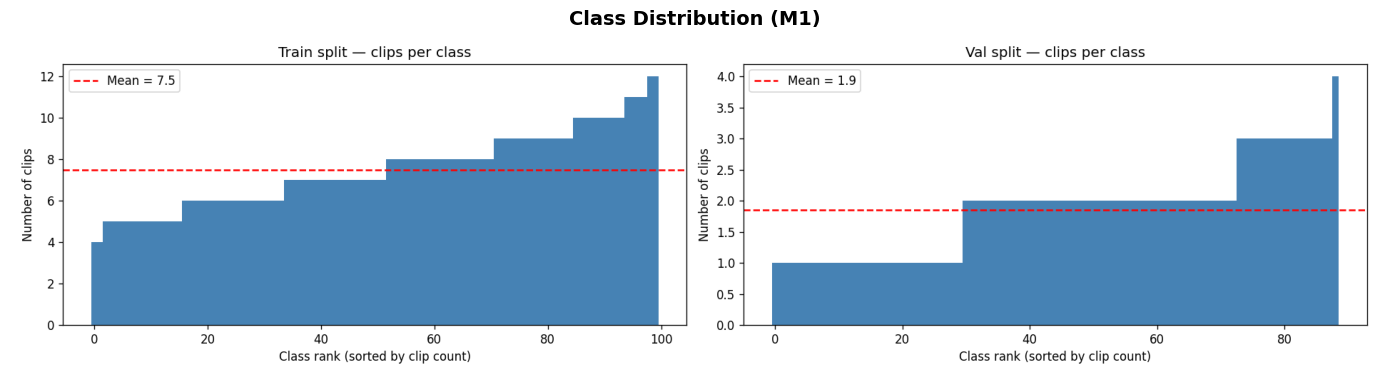

✅ Class Distribution (M1)


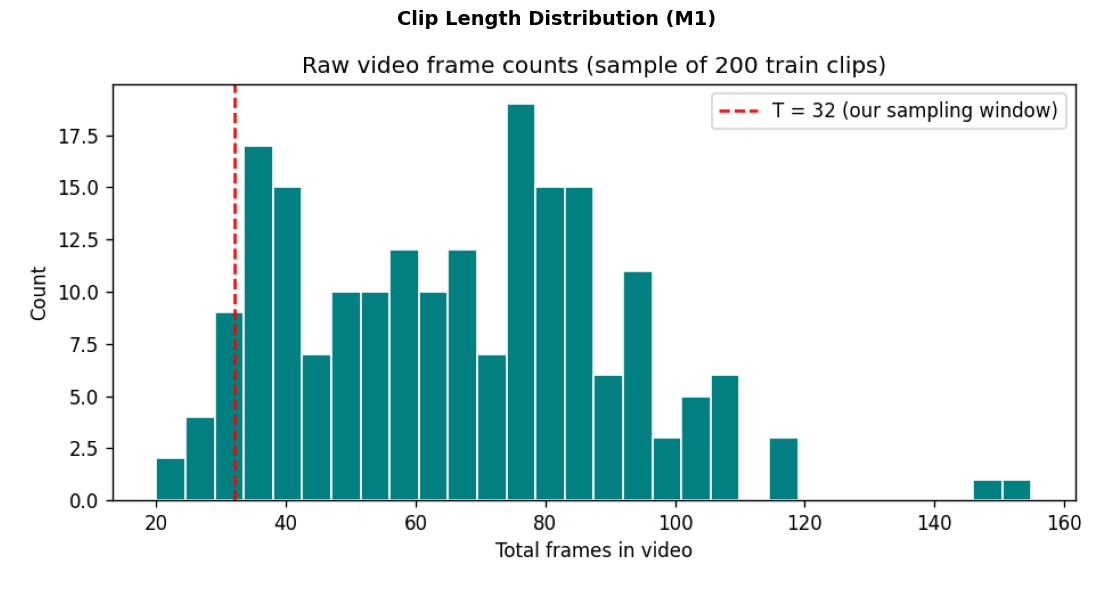

✅ Clip Length Distribution (M1)


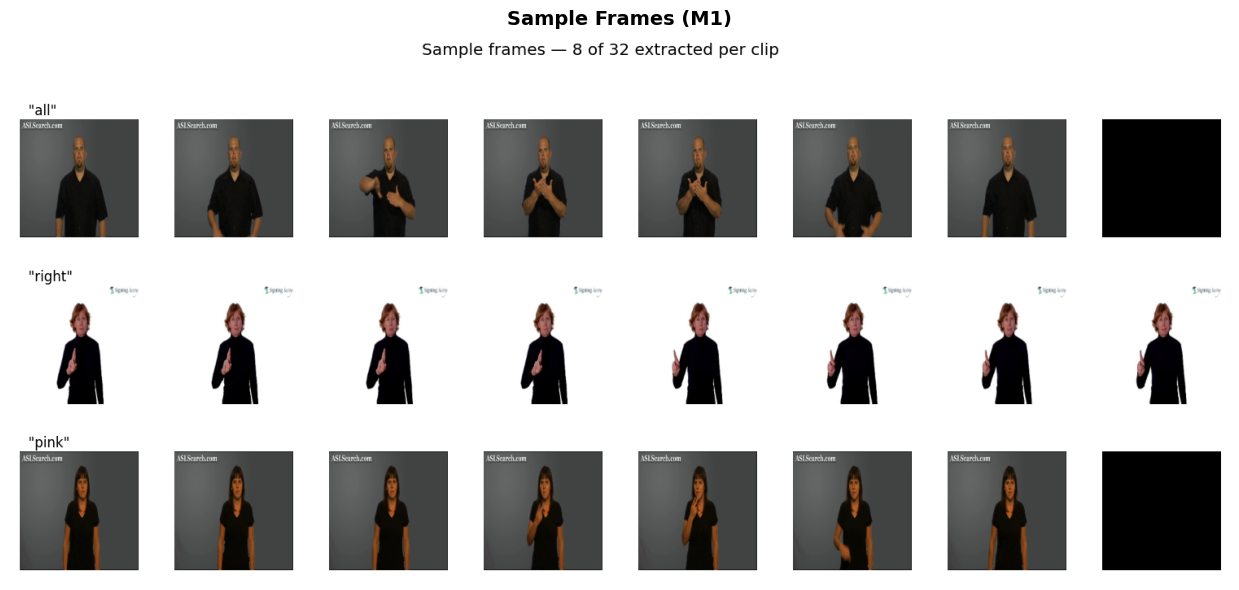

✅ Sample Frames (M1)


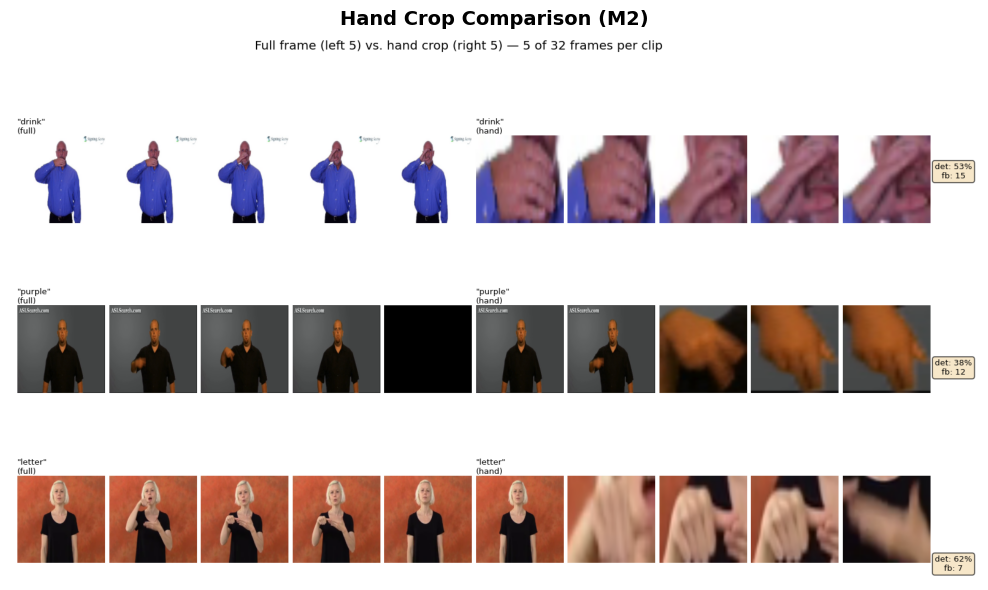

✅ Hand Crop Comparison (M2)


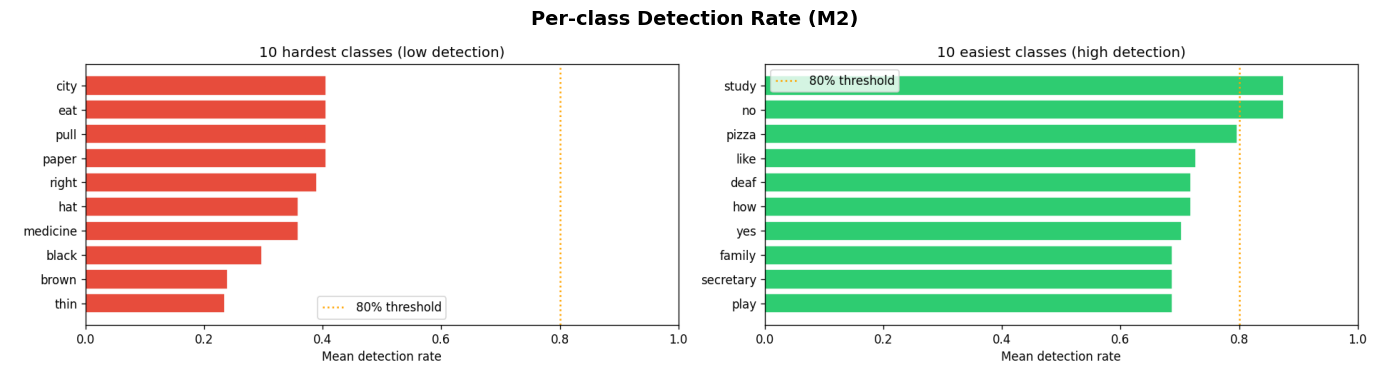

✅ Per-class Detection Rate (M2)


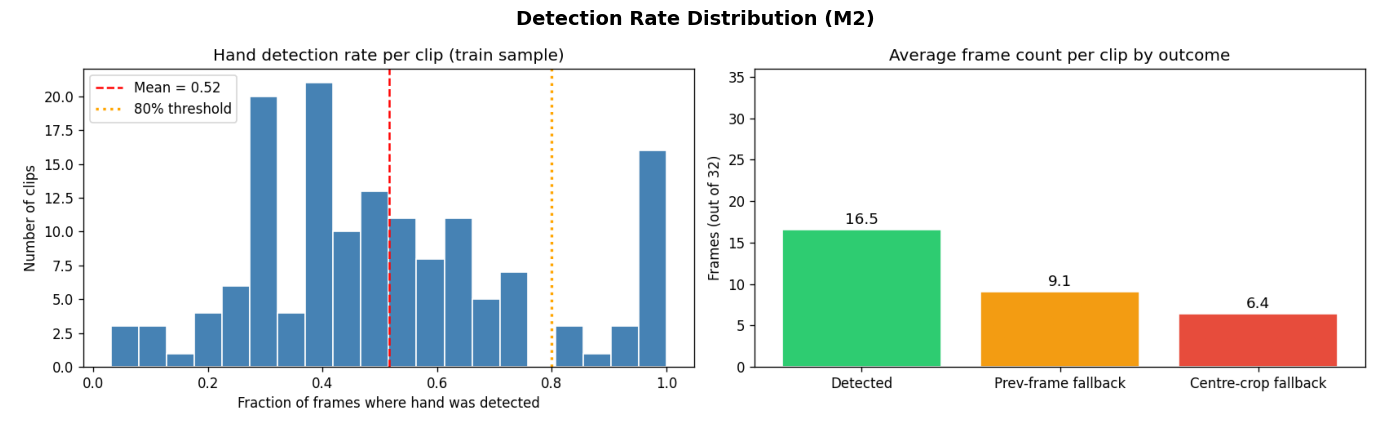

✅ Detection Rate Distribution (M2)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

EDA_PLOTS = [
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\data_prep_output\EDA\class_distribution.png',           'Class Distribution (M1)'),
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\data_prep_output\EDA\clip_length_distribution.png',      'Clip Length Distribution (M1)'),
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\data_prep_output\EDA\sample_frames.png',                 'Sample Frames (M1)'),
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\Hand_detection_output\hand_crop_comparison.png',         'Hand Crop Comparison (M2)'),
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\Hand_detection_output\per_class_detection.png',          'Per-class Detection Rate (M2)'),
    (r'C:\Users\OMEN\OneDrive\Desktop\Artificial Neural Network\ANNproject\Hand_detection_output\detection_rate_distribution.png',  'Detection Rate Distribution (M2)'),
]

for path, title in EDA_PLOTS:
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(14, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f'✅ {title}')
    else:
        print(f'❌ Not found: {path}')